In [1]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit


In [2]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [5]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [7]:
def hybrid_ernn_loss(y, e_hybrid, sigma, tau):
    """
    Hybrid ERNN AGD NLL Loss
    y        : observed returns (tensor), shape (T,)
    e_hybrid : hybrid expectile estimate (tensor), shape (T,)
               = psi * CARE_component + (1-psi) * FNN_component
    sigma    : scale parameter (scalar)
    tau      : expectile level in (0,1)
    """
    diff = y - e_hybrid
    omega = torch.abs(tau - (diff < 0).float()) * diff**2
    nll = (torch.log(sigma)
           + torch.log(torch.sqrt(torch.tensor(torch.pi / tau))
                       + torch.sqrt(torch.tensor(torch.pi / (1 - tau))))
           - torch.log(torch.tensor(2.0))
           + omega / sigma**2)
    return nll.mean()


def compute_hybrid_location_self_si(y, X, gamma1, gamma2, gamma3, fnn_model, psi):
    """
    Self-lagged hybrid ERNN location -- SI (self-interaction) functional form.
    The CARE component uses the previous pure CARE output as its autoregressive input.
    SI form: e_t = gamma1 * e_{t-1} + gamma2 * |y_{t-1}| + gamma3 * e_{t-1} * |y_{t-1}|

    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    gamma1 : expectile persistence, constrained to (0,1)
    gamma2 : magnitude impact, constrained to >0
    gamma3 : interaction term, constrained to >0
    psi    : mixing weight, constrained to (0,1)
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)  # shape (T,)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CARE component -- SI self-lagged
        abs_y    = torch.abs(y[t-1])
        care_t   = (gamma1 * e_care_list[t-1]
                  + gamma2 * abs_y
                  + gamma3 * e_care_list[t-1] * abs_y)
        e_care_list.append(care_t)

        # Hybrid combination
        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care

In [9]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

## TUning

In [12]:
def compute_hybrid_location_self_si(y, X, gamma1, gamma2, gamma3, fnn_model, psi):
    """
    Self-lagged hybrid ERNN location -- SI (self-interaction) functional form.
    The CARE component uses the previous pure CARE output as its autoregressive input.
    SI form: e_t = gamma1 * e_{t-1} + gamma2 * |y_{t-1}| + gamma3 * e_{t-1} * |y_{t-1}|
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    e_care_list   = [torch.zeros(1)]
    e_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        abs_y  = torch.abs(y[t-1])
        care_t = (gamma1 * e_care_list[t-1]
                + gamma2 * abs_y
                + gamma3 * e_care_list[t-1] * abs_y)
        e_care_list.append(care_t)

        hybrid_t = psi * care_t + (1 - psi) * fnn_out[t]
        e_hybrid_list.append(hybrid_t)

    e_care   = torch.stack(e_care_list).squeeze(-1)
    e_hybrid = torch.stack(e_hybrid_list).squeeze(-1)

    return e_hybrid, e_care


class HybridERNN_SI(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.gamma1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.gamma2_raw = nn.Parameter(torch.tensor(0.3))
        self.gamma3_raw = nn.Parameter(torch.tensor(0.3))     # interaction term
        self.psi_raw    = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw  = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        gamma1 = torch.sigmoid(self.gamma1_raw)
        gamma2 = torch.nn.functional.softplus(self.gamma2_raw)
        gamma3 = torch.nn.functional.softplus(self.gamma3_raw)
        psi    = torch.sigmoid(self.psi_raw)
        sigma  = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged SI: uses previous pure CARE output
        e_hybrid, e_care = compute_hybrid_location_self_si(
            y, X, gamma1, gamma2, gamma3, self.fnn, psi)

        return e_hybrid, sigma


def compute_crp(y, q, alpha):
    """
    Coverage Ratio Penalty (CRP).
    For alpha <= 0.5: count violations where y <= q (lower tail).
    For alpha >  0.5: count violations where y >  q (upper tail).
    CRP = empirical_coverage / alpha*
    Penalty = (CRP - 1)^2
    """
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective(trial, tau):
    # Optuna only tunes architecture and training hyperparameters
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridERNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        crp, crp_penalty = compute_crp(y_val, e_val, tau)

        gamma1 = torch.sigmoid(model.gamma1_raw).item()
        gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        psi    = torch.sigmoid(model.psi_raw).item()
        sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('gamma1',      gamma1)
    trial.set_user_attr('gamma2',      gamma2)
    trial.set_user_attr('gamma3',      gamma3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"tau={tau} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"gamma1={gamma1:.4f} | gamma2={gamma2:.4f} | gamma3={gamma3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    """
    Rank all completed trials by NLL and CRP_penalty separately.
    Select trial with lowest sum of ranks.
    Tiebreak: raw NLL, then raw CRP_penalty, then trial number.
    """
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each tau level
# -------------------------
tau_levels           = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed            = 2026
best_configs_ernn_si_self = {}  # distinct name for SI self-lagged

for i, tau in enumerate(tau_levels):
    print(f"\n{'='*60}")
    print(f"Tuning ERNN SI Self-lagged for tau = {tau} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, t=tau: objective(trial, tau=t),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for tau={tau}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'tau':         tau,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'gamma1':      t.user_attrs['gamma1'],
            'gamma2':      t.user_attrs['gamma2'],
            'gamma3':      t.user_attrs['gamma3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'ernn_si_self_ranking_tau_{tau}.csv', index=False)
    print(f"  Full ranking saved to ernn_si_self_ranking_tau_{tau}.csv")

    best_configs_ernn_si_self[tau] = best_trial.params.copy()
    best_configs_ernn_si_self[tau]['tau'] = tau

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridERNN_SI(X_train.shape[1], best_configs_ernn_si_self[tau])

    if best_configs_ernn_si_self[tau]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_ernn_si_self[tau]['lr'],
                                     weight_decay=best_configs_ernn_si_self[tau]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_ernn_si_self[tau]['lr'],
                                      weight_decay=best_configs_ernn_si_self[tau]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_ernn_si_self[tau]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            e_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_ernn_si_self[tau].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        e_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_ernn_loss(y_val, e_val_final, sigma_val_final, tau).item()
        final_crp, final_crp_penalty = compute_crp(y_val, e_val_final, tau)

        est_gamma1 = torch.sigmoid(best_model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(best_model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(best_model.gamma3_raw).item()
        est_psi    = torch.sigmoid(best_model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_ernn_si_self[tau]['est_psi']    = est_psi
    best_configs_ernn_si_self[tau]['est_sigma']  = est_sigma
    best_configs_ernn_si_self[tau]['est_gamma1'] = est_gamma1
    best_configs_ernn_si_self[tau]['est_gamma2'] = est_gamma2
    best_configs_ernn_si_self[tau]['est_gamma3'] = est_gamma3
    best_configs_ernn_si_self[tau]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:    {est_psi:.4f}")
    print(f"Estimated sigma:  {est_sigma:.4f}")
    print(f"Estimated gamma1: {est_gamma1:.4f}")
    print(f"Estimated gamma2: {est_gamma2:.4f}")
    print(f"Estimated gamma3: {est_gamma3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- ERNN SI SELF-LAGGED")
print("="*60)
for tau, config in best_configs_ernn_si_self.items():
    print(f"tau={tau}: {config}")

[I 2026-07-07 00:27:28,556] A new study created in memory with name: no-name-0ce8e979-bb09-45a3-b00d-83e95d89cdeb



Tuning ERNN SI Self-lagged for tau = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=1.8465 | CRP=0.1766 | CRP_penalty=0.6780 | tau=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | gamma1=0.7998 | gamma2=0.8540 | gamma3=0.8540
[I 2026-07-07 00:27:32,144] Trial 0 finished with value: 1.8464511632919312 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 1.8464511632919312.
  Trial 1: NLL=1.8299 | CRP=0.0883 | CRP_penalty=0.8312 | tau=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5063 | sigma=0.9548 | gamma1=0.7985 | gamma2=0.8483 | gamma3=0.8462
[I 2026-07-07 00:27:50,329] Trial 1 finished with value: 1.8299404382705688 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'laye

[I 2026-07-07 01:26:12,590] A new study created in memory with name: no-name-d5d46aac-2ea5-4c30-9d2c-43341d26739b


...

  Trial 0: NLL=0.4225 | CRP=0.2208 | CRP_penalty=0.6072 | tau=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5152 | sigma=0.3128 | gamma1=0.7705 | gamma2=0.7163 | gamma3=0.6575
[I 2026-07-07 14:35:48,951] Trial 0 finished with value: 0.4225331246852875 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 0.4225331246852875.
  Trial 1: NLL=0.7172 | CRP=0.6181 | CRP_penalty=0.1458 | tau=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5149 | sigma=0.4202 | gamma1=0.7855 | gamma2=0.7878 | gamma3=0.7431
[I 2026-07-07 14:36:09,123] Trial 1 finished with value: 0.7171754837036133 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 

[I 2026-07-10 00:48:20,868] A new study created in memory with name: no-name-2f5b81a6-d6b7-4b71-8a65-dab210769f49



Best trial (rank-based): #176
  NLL rank: 10 | CRP rank: 4 | Sum: 14
Final NLL:          -2.4179
Final CRP:          1.0596
Final CRP penalty:  0.0036
Best params: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.039061295713491206, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.04554288942227808, 'optimizer': 'adamw', 'batch_size': 128, 'weight_decay': 6.393990744853923e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 145}
Estimated psi:    0.7382
Estimated sigma:  0.0135
Estimated gamma1: 0.6046
Estimated gamma2: 0.0897
Estimated gamma3: 0.1361

Tuning ERNN SI Self-lagged for tau = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=0.6325 | CRP=2.1192 | CRP_penalty=1.2526 | tau=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5177 | sigma=0.2892 | gamma1=0.7521 | gamma2=0.6977 | gamma3=0.6279
[I 2026-07-10 00:48:43,052] Trial 0 finished with value: 0.6325122714042664 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 0.6325122714042664.
  Trial 1: NLL=1.8292 | CRP=3.6203 | CRP_penalty=6.8660 | tau=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5019 | sigma=0.9572 | gamma1=0.8009 | gamma2=0.8579 | gamma3=0.8569
[I 2026-07-10 00:49:03,325] Trial 1 finished with value: 1.829203724861145 and parameters: {'n_hidden_layers': 1, 'activation': 'e


Training final model for tau = 0.025 (SI self-lagged)
  Epoch 50: train=0.0493, val=-0.0005
  Epoch 100: train=-1.7716, val=-1.9995
  Epoch 150: train=-2.0573, val=-2.3119
  Early stopping at epoch 198
  Test loss: -2.4564 | gamma1=0.4005 | gamma2=0.0889 | gamma3=0.1621 | psi=0.7285 | sigma=0.0115

Training final model for tau = 0.05 (SI self-lagged)
  Epoch 50: train=-0.3273, val=-0.3776
  Epoch 100: train=-1.7803, val=-1.9560
  Epoch 150: train=-2.1672, val=-2.3605
  Epoch 200: train=-2.2173, val=-2.3857
  Test loss: -2.4850 | gamma1=0.3725 | gamma2=0.0700 | gamma3=0.1131 | psi=0.9192 | sigma=0.0136

Training final model for tau = 0.25 (SI self-lagged)
  Epoch 50: train=-0.4327, val=-0.4872
  Epoch 100: train=-1.7862, val=-1.8900
  Epoch 150: train=-2.1084, val=-2.2908
  Epoch 200: train=-2.0371, val=-2.5464
  Test loss: -2.6517 | gamma1=0.4846 | gamma2=0.1135 | gamma3=0.1708 | psi=0.7585 | sigma=0.0215

Training final model for tau = 0.5 (SI self-lagged)
  Epoch 50: train=-0.4148, 

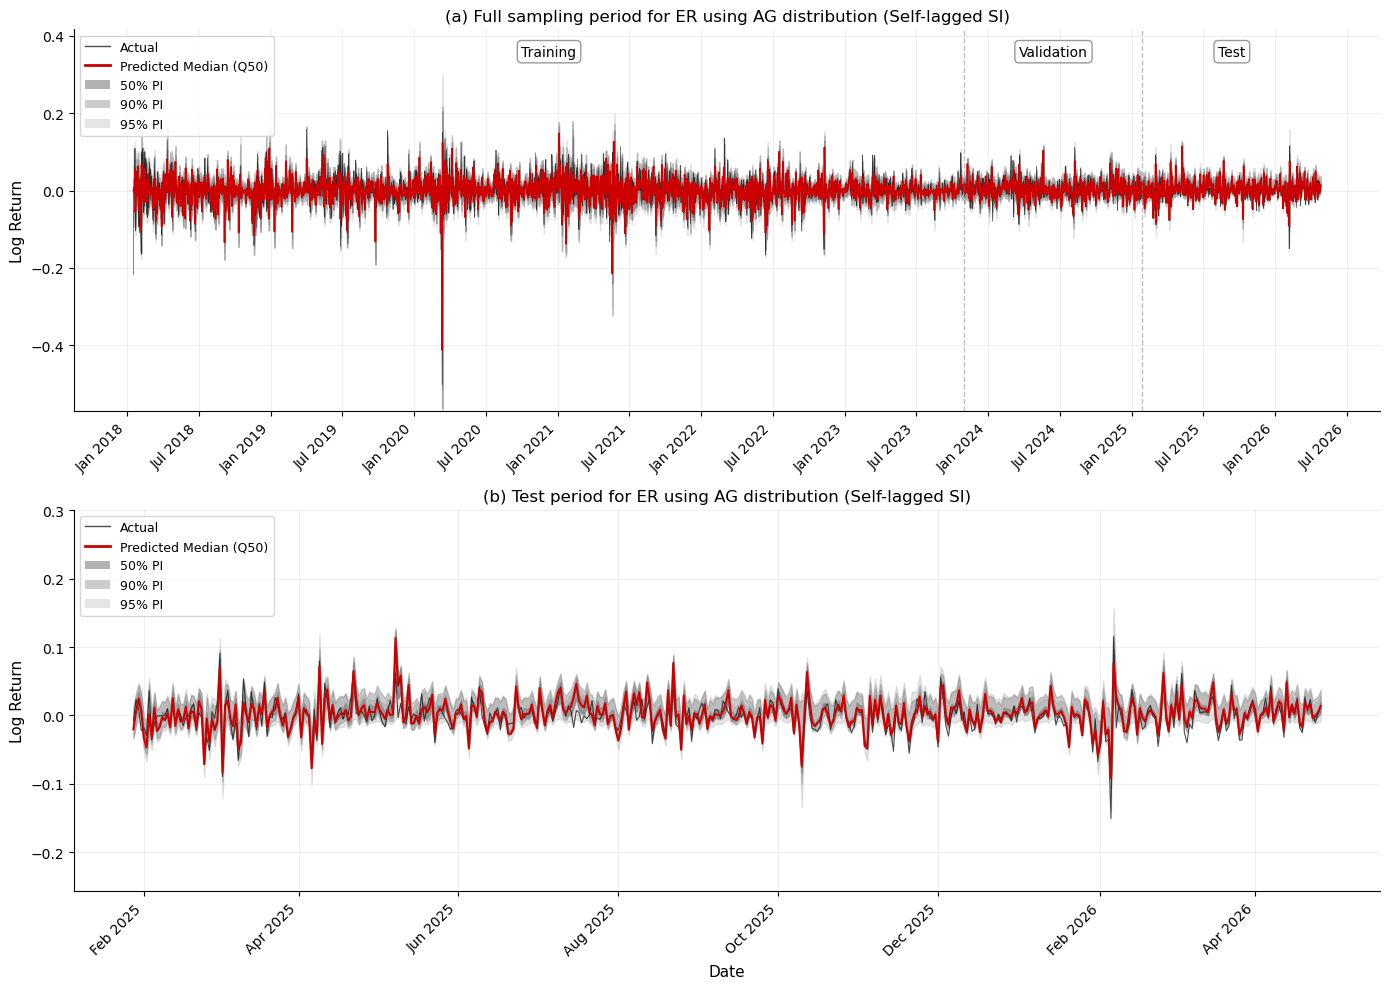

Full period plot saved to hybrid_ernn_self_si_predictions_full.png
Test period plot saved to hybrid_ernn_self_si_predictions_test.png

CROSSOVER ANALYSIS -- ERNN Self SI (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           5      1.10% <-- TAIL
  (0.050, 0.250):         118     25.99%
  (0.250, 0.500):          86     18.94%
  (0.500, 0.750):           0      0.00%
  (0.750, 0.950):           2      0.44%
  (0.950, 0.975):         229     50.44% <-- TAIL
  ------------------------------------------
  Total violations:         440  (16.15% of all pairs)
  Tail violations:          234  (25.77% of tail pairs)


In [14]:
def train_final_model_ernn_si(tau, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridERNN_SI(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        e_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_ernn_loss(y_train, e_hybrid, sigma, tau)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            e_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_ernn_loss(y_val, e_val, sigma_val, tau)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        e_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_ernn_loss(y_test, e_test, sigma_test, tau)

    with torch.no_grad():
        est_gamma1 = torch.sigmoid(model.gamma1_raw).item()
        est_gamma2 = torch.nn.functional.softplus(model.gamma2_raw).item()
        est_gamma3 = torch.nn.functional.softplus(model.gamma3_raw).item()
        est_psi    = torch.sigmoid(model.psi_raw).item()
        est_sigma  = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | "
          f"gamma1={est_gamma1:.4f} | gamma2={est_gamma2:.4f} | "
          f"gamma3={est_gamma3:.4f} | psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'ernn_si_self_history_tau_{tau}.csv', index=False)

    return model, train_losses, val_losses, e_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all tau levels
# -------------------------
tau_levels           = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_ernn_si_self = {}

for tau in tau_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for tau = {tau} (SI self-lagged)")
    print(f"{'='*60}")
    config = best_configs_ernn_si_self[tau]
    model, train_losses, val_losses, e_test_pred = train_final_model_ernn_si(
        tau, config, y_train, X_train, y_val, X_val, y_test, X_test)
    results_ernn_si_self[tau] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'e_test':       e_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel(results, train_df, val_df, test_df, tau_levels, feature_cols,
                   title_suffix='ER using AG distribution (Self-lagged SI)',
                   save_fname='hybrid_ernn_self_si_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()
        with torch.no_grad():
            e_all, _ = model(y_all, X_all)
            all_preds[tau] = e_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=1.5)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- SI self-lagged
# -------------------------
all_preds_ernn_si_self, train_size, val_size = plot_two_panel(
    results_ernn_si_self, train_df, val_df, test_df, tau_levels, feature_cols,
    title_suffix='ER using AG distribution (Self-lagged SI)',
    save_fname='hybrid_ernn_self_si_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='ERNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


total_viol, tail_viol = compute_crossovers(
    all_preds_ernn_si_self, tau_levels, train_size, val_size,
    model_name='ERNN Self SI'
)

In [16]:
import numpy as np


def compute_ase(y_true, e_pred, tau):
    """
    Asymmetric Squared Error for expectile evaluation.
    ASE = mean(|tau - 1(y < e_hat)| * (y - e_hat)^2)
    """
    y         = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    e         = e_pred if isinstance(e_pred, np.ndarray) else np.array(e_pred)
    indicator = (y < e).astype(float)
    ase       = np.mean(np.abs(tau - indicator) * (y - e)**2)
    return ase


def compute_test_metrics_ernn(results, tau_levels, y_test, X_test, model_name='ERNN'):
    """
    Compute average NLL and ASE on test set across all tau levels.
    """
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'tau':>6} {'NLL':>10} {'ASE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    ase_list = []

    for tau in tau_levels:
        model = results[tau]['model']
        model.eval()

        with torch.no_grad():
            e_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_ernn_loss(y_test, e_test, sigma_test, tau).item()

        e_test_np = e_test.numpy()
        y_test_np = y_test.numpy()

        ase = compute_ase(y_test_np, e_test_np, tau)

        nll_list.append(test_nll)
        ase_list.append(ase)

        print(f"  {tau:>6} {test_nll:>10.4f} {ase:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(ase_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average ASE: {np.mean(ase_list):.6f}")

    return np.mean(nll_list), np.mean(ase_list)


# -------------------------
# Test tensors
# -------------------------
X_test = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

tau_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]

# -------------------------
# Run metrics -- ERNN SI self-lagged
# -------------------------
avg_nll_ernn_si_self, avg_ase_ernn_si_self = compute_test_metrics_ernn(
    results_ernn_si_self, tau_levels, y_test, X_test,
    model_name='ERNN SI Self-lagged'
)


TEST SET METRICS -- ERNN SI Self-lagged
     tau        NLL            ASE
  ----------------------------------
   0.025    -2.4564       0.000018
    0.05    -2.4850       0.000042
    0.25    -2.6517       0.000074
     0.5    -2.7248       0.000089
    0.75    -2.6550       0.000074
    0.95    -2.4481       0.000050
   0.975    -2.4644       0.000026
  ----------------------------------
    Mean    -2.5551       0.000053

  --> Average NLL: -2.5551
  --> Average ASE: 0.000053


# Cross over dealing

In [19]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Joint ERNN SI Self-lagged
# One model estimates all seven expectile levels
# ============================================================

tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]


class HybridERNN_SI_Self_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(tau_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets
        self.gamma1_raw = nn.Parameter(
            torch.full((self.n_levels,), 1.386)
        )
        self.gamma2_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.gamma3_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.3)
        )
        self.psi_raw = nn.Parameter(
            torch.zeros(self.n_levels)
        )
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        # Shared FNN
        layers = []
        prev_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']

            layers.append(
                nn.Linear(prev_dim, hidden_dim)
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(config['dropout'])
                )

            prev_dim = hidden_dim

        # Median expectile plus six raw spacings
        layers.append(
            nn.Linear(prev_dim, self.n_levels)
        )

        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_expectiles(self, raw_fnn):
        median = raw_fnn[:, 0]
        delta = (
            F.softplus(raw_fnn[:, 1:])
            + self.eps
        )

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        return torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

    def forward(
        self,
        y,
        X,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )
        gamma2 = F.softplus(
            self.gamma2_raw
        )
        gamma3 = F.softplus(
            self.gamma3_raw
        )
        psi = torch.sigmoid(
            self.psi_raw
        )
        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        raw_fnn = self.fnn(X)

        fnn_expectiles = (
            self.reconstruct_fnn_expectiles(
                raw_fnn
            )
        )

        e_hybrid, e_care = (
            compute_hybrid_location_self_si_joint(
                y=y,
                fnn_expectiles=fnn_expectiles,
                gamma1=gamma1,
                gamma2=gamma2,
                gamma3=gamma3,
                psi=psi,
                initial_care=initial_care,
                initial_y=initial_y
            )
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            fnn_expectiles
        )


def compute_hybrid_location_self_si_joint(
    y,
    fnn_expectiles,
    gamma1,
    gamma2,
    gamma3,
    psi,
    initial_care=None,
    initial_y=None
):
    """
    Self-lagged self-interaction CARE recursion:

    e^S_{k,t}
    = gamma1_k e^S_{k,t-1}
    + gamma2_k |y_{t-1}|
    + gamma3_k e^S_{k,t-1}|y_{t-1}|

    e^H_{k,t}
    = psi_k e^S_{k,t}
    + (1-psi_k) f_{k,t}
    """
    T = len(y)
    n_levels = fnn_expectiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    e_hybrid_list = []
    e_care_list = []

    has_initial_state = (
        initial_care is not None
        and initial_y is not None
    )

    if (
        (initial_care is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_care and initial_y '
            'must be supplied together.'
        )

    previous_care = (
        initial_care
        if has_initial_state
        else zero_row
    )

    for t in range(T):
        if t == 0 and not has_initial_state:
            e_care_list.append(zero_row)
            e_hybrid_list.append(zero_row)
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        abs_y = torch.abs(previous_y)

        care_t = (
            gamma1 * previous_care
            + gamma2 * abs_y
            + gamma3 * previous_care * abs_y
        )

        hybrid_t = (
            psi * care_t
            + (1 - psi) * fnn_expectiles[t]
        )

        e_care_list.append(care_t)
        e_hybrid_list.append(hybrid_t)

        # Self-lagged: use previous pure CARE output
        previous_care = care_t

    e_care = torch.stack(
        e_care_list,
        dim=0
    )
    e_hybrid = torch.stack(
        e_hybrid_list,
        dim=0
    )

    return e_hybrid, e_care


# ============================================================
# Joint AGD loss, ASE and crossover
# ============================================================

def hybrid_ernn_joint_loss(
    y,
    e_hybrid,
    sigma,
    levels=tau_levels
):
    """
    Average AGD negative log-likelihood across
    all observations and seven expectile levels.
    """
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )
    omega = weight * u.pow(2)

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau
            )
            + torch.sqrt(
                torch.pi / (1 - tau)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma).unsqueeze(0)
        + constant.unsqueeze(0)
        + omega / sigma.pow(2).unsqueeze(0)
    )

    return nll.mean()


def compute_ase_joint(
    y,
    e_hybrid,
    levels=tau_levels
):
    tau = torch.tensor(
        levels,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    u = y.unsqueeze(1) - e_hybrid
    weight = torch.abs(
        tau.unsqueeze(0)
        - (u < 0).float()
    )

    ase_by_level = (
        weight * u.pow(2)
    ).mean(dim=0)

    return (
        ase_by_level,
        ase_by_level.mean()
    )


def compute_crossover_joint(e_hybrid):
    violations = (
        e_hybrid[:, :-1]
        > e_hybrid[:, 1:]
    )

    pair_counts = violations.sum(dim=0)
    T = len(e_hybrid)

    total_count = int(
        pair_counts.sum().item()
    )
    total_rate = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item()
        + pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x)
            for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate': total_rate,
        'tail_count': tail_count,
        'tail_rate': tail_rate
    }


# ============================================================
# Fit one joint model
# ============================================================

def fit_joint_ernn_si_self(
    config,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridERNN_SI_Self_Joint(
        X_train.shape[1],
        config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        e_train, sigma, _, _ = model(
            y_train,
            X_train
        )

        # t=0 is only the initialisation row
        train_loss = hybrid_ernn_joint_loss(
            y_train[1:],
            e_train[1:],
            sigma
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Continue validation from training CARE state
        model.eval()
        with torch.no_grad():
            _, sigma_val, care_train, _ = model(
                y_train,
                X_train
            )

            e_val, _, _, _ = model(
                y_val,
                X_val,
                initial_care=care_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_ernn_joint_loss(
                y_val,
                e_val,
                sigma_val
            )

        scheduler.step(
            val_loss.item()
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


def evaluate_joint_ernn_si_self(model):
    model.eval()

    with torch.no_grad():
        _, sigma, care_train, _ = model(
            y_train,
            X_train
        )

        e_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_care=care_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_ernn_joint_loss(
            y_val,
            e_val,
            sigma
        ).item()

        ase_levels, mean_ase = (
            compute_ase_joint(
                y_val,
                e_val
            )
        )

        final_cross = (
            compute_crossover_joint(e_val)
        )
        fnn_cross = (
            compute_crossover_joint(fnn_val)
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        )
        gamma2 = F.softplus(
            model.gamma2_raw
        )
        gamma3 = F.softplus(
            model.gamma3_raw
        )
        psi = torch.sigmoid(
            model.psi_raw
        )
        sigma = (
            F.softplus(model.sigma_raw)
            + model.eps
        )

    return {
        'mean_nll': mean_nll,
        'ase_by_level': ase_levels.tolist(),
        'mean_ase': mean_ase.item(),
        'final_crossover': final_cross,
        'fnn_crossover': fnn_cross,
        'gamma1': gamma1.tolist(),
        'gamma2': gamma2.tolist(),
        'gamma3': gamma3.tolist(),
        'psi': psi.tolist(),
        'sigma': sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_ernn_si_self_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    model = fit_joint_ernn_si_self(
        config=config,
        max_epochs=200,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_ernn_si_self(
        model
    )

    for name in [
        'mean_nll',
        'mean_ase',
        'ase_by_level',
        'gamma1',
        'gamma2',
        'gamma3',
        'psi',
        'sigma'
    ]:
        trial.set_user_attr(
            name,
            metrics[name]
        )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    print(
        f"Trial {trial.number}: "
        f"NLL={metrics['mean_nll']:.6f} | "
        f"ASE={metrics['mean_ase']:.8f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Search is guided by validation NLL.
    # Final selection uses NLL rank + ASE rank.
    return metrics['mean_nll']


# ============================================================
# Rank by validation NLL and ASE
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if (
            t.state
            == optuna.trial.TrialState.COMPLETE
            and t.value is not None
            and np.isfinite(t.value)
            and 'mean_nll' in t.user_attrs
            and 'mean_ase' in t.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._ase = t.user_attrs['mean_ase']

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._nll
        ),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(
            trials,
            key=lambda x: x._ase
        ),
        start=1
    ):
        t._rank_ase = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_ase,
            t._nll,
            t._ase,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one 800-trial joint study
# ============================================================

print('\n' + '=' * 70)
print(
    'Tuning Joint ERNN SI Self-lagged '
    'for all seven tau levels'
)
print('=' * 70)

sampler = TPESampler(seed=2026)

study_ernn_si_self_joint = (
    optuna.create_study(
        direction='minimize',
        sampler=sampler
    )
)

study_ernn_si_self_joint.optimize(
    objective_ernn_si_self_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial_ernn_si_self, all_trials_ernn_si_self = (
    select_best_trial_by_rank_joint(
        study_ernn_si_self_joint
    )
)


# ============================================================
# Save trial ranking
# ============================================================

ranking_records = []

for t in all_trials_ernn_si_self:
    record = {
        'trial': t.number,
        'mean_nll': t._nll,
        'mean_ase': t._ase,
        'rank_nll': t._rank_nll,
        'rank_ase': t._rank_ase,
        'sum_rank': (
            t._rank_nll + t._rank_ase
        ),
        'final_crossover_count':
            t.user_attrs[
                'final_crossover_count'
            ],
        'final_crossover_rate':
            t.user_attrs[
                'final_crossover_rate'
            ],
        'tail_crossover_count':
            t.user_attrs[
                'tail_crossover_count'
            ],
        'tail_crossover_rate':
            t.user_attrs[
                'tail_crossover_rate'
            ],
        'fnn_crossover_count':
            t.user_attrs[
                'fnn_crossover_count'
            ]
    }

    for k, tau in enumerate(tau_levels):
        suffix = f'tau_{tau}'

        record[f'ase_{suffix}'] = (
            t.user_attrs['ase_by_level'][k]
        )
        record[f'gamma1_{suffix}'] = (
            t.user_attrs['gamma1'][k]
        )
        record[f'gamma2_{suffix}'] = (
            t.user_attrs['gamma2'][k]
        )
        record[f'gamma3_{suffix}'] = (
            t.user_attrs['gamma3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df_ernn_si_self = pd.DataFrame(
    ranking_records
)

ranking_df_ernn_si_self = (
    ranking_df_ernn_si_self.sort_values(
        ['sum_rank', 'mean_nll', 'mean_ase']
    )
)

ranking_df_ernn_si_self.to_csv(
    'joint_ernn_si_self_ranking.csv',
    index=False
)


# ============================================================
# Refit and save selected model
# ============================================================

best_config_ernn_si_self = (
    best_trial_ernn_si_self.params.copy()
)

best_model_ernn_si_self_joint = (
    fit_joint_ernn_si_self(
        config=best_config_ernn_si_self,
        max_epochs=200,
        seed=2026
    )
)

best_metrics_ernn_si_self_joint = (
    evaluate_joint_ernn_si_self(
        best_model_ernn_si_self_joint
    )
)

torch.save(
    {
        'model_state_dict':
            best_model_ernn_si_self_joint.state_dict(),
        'config':
            best_config_ernn_si_self,
        'tau_levels':
            tau_levels,
        'validation_metrics':
            best_metrics_ernn_si_self_joint
    },
    'joint_ernn_si_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- JOINT ERNN SI SELF-LAGGED')
print('=' * 70)
print(
    f'Best trial: {best_trial_ernn_si_self.number}'
)
print(
    f"Validation NLL: "
    f"{best_metrics_ernn_si_self_joint['mean_nll']:.6f}"
)
print(
    f"Validation ASE: "
    f"{best_metrics_ernn_si_self_joint['mean_ase']:.8f}"
)
print(
    f"Final hybrid crossover: "
    f"{best_metrics_ernn_si_self_joint['final_crossover']['total_count']} "
    f"("
    f"{best_metrics_ernn_si_self_joint['final_crossover']['total_rate']:.2%}"
    f")"
)
print(
    f"Tail crossover: "
    f"{best_metrics_ernn_si_self_joint['final_crossover']['tail_count']} "
    f"("
    f"{best_metrics_ernn_si_self_joint['final_crossover']['tail_rate']:.2%}"
    f")"
)
print(
    f"FNN crossover count: "
    f"{best_metrics_ernn_si_self_joint['fnn_crossover']['total_count']}"
)
print(
    f'Best architecture: {best_config_ernn_si_self}'
)

[I 2026-07-28 14:03:07,539] A new study created in memory with name: no-name-ee9d4457-59df-4fd8-97f6-944bc7001c8d



Tuning Joint ERNN SI Self-lagged for all seven tau levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: NLL=1.301424 | ASE=0.00233009 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-28 14:03:29,589] Trial 0 finished with value: 1.3014237880706787 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.3014237880706787.
Trial 1: NLL=0.266581 | ASE=0.00018905 | Final crossover=0.15% | FNN crossover=0.00%
[I 2026-07-28 14:03:50,107] Trial 1 finished with value: 0.2665809392929077 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2665809392929077.
Trial 2: NLL=1.3805

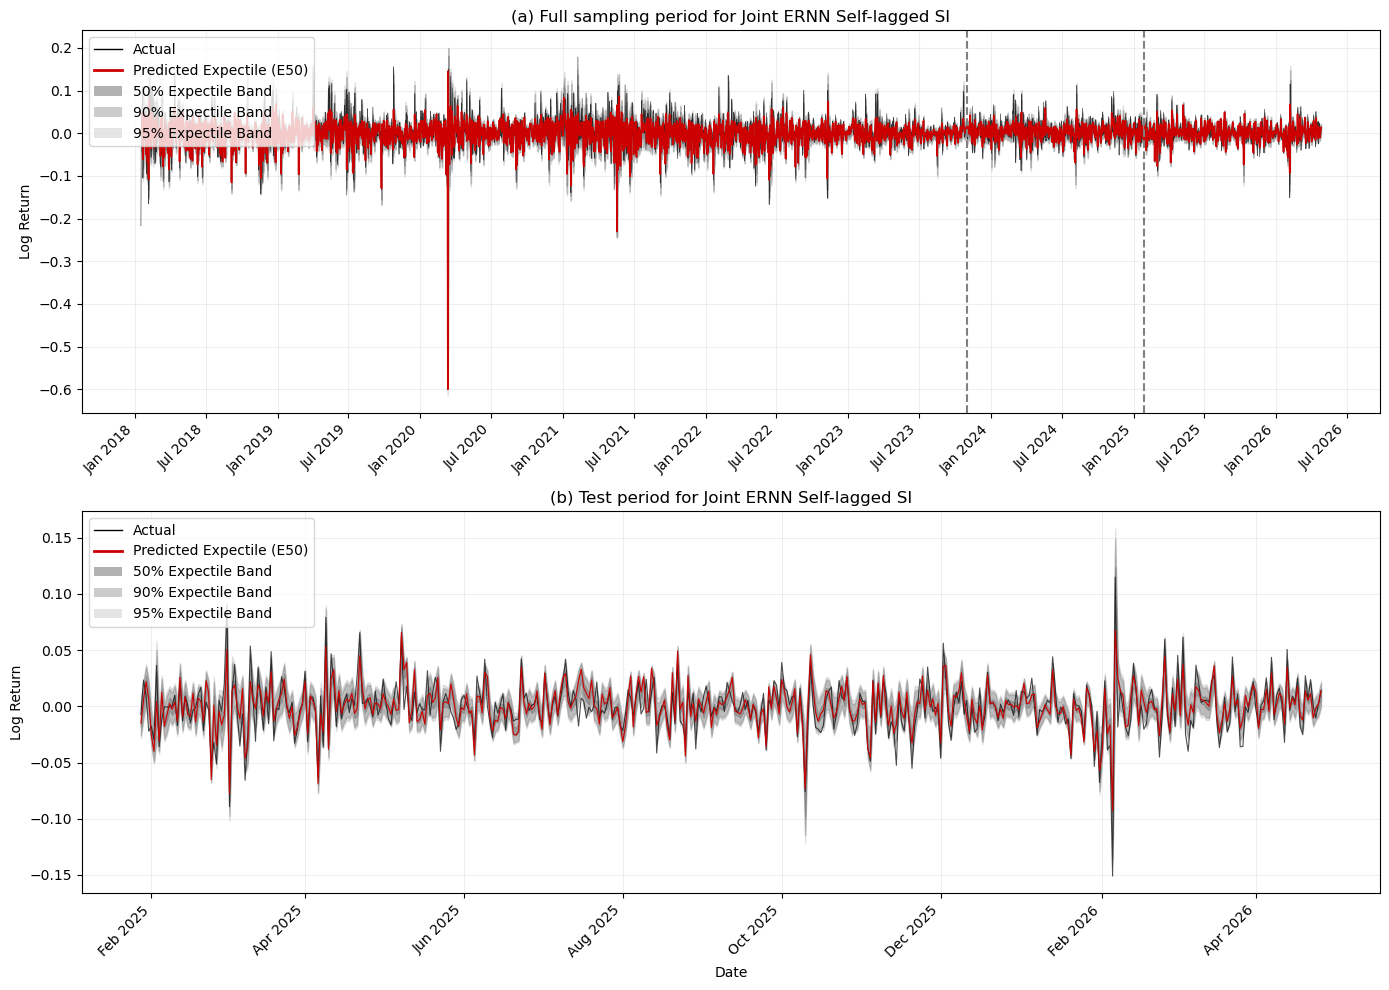

Plot saved to hybrid_ernn_self_si_joint_predictions.png

TEST METRICS -- JOINT ERNN SI SELF-LAGGED
       tau         NLL        ASE
0.02500000 -2.62879062 0.00001586
0.05000000 -2.66488481 0.00002613
0.25000000 -2.71359158 0.00007122
0.50000000 -2.72503877 0.00008054
0.75000000 -2.79896092 0.00005905
0.95000000 -2.73043776 0.00002295
0.97500000 -2.67986035 0.00001446

Average NLL: -2.705938
Average ASE: 0.00004146

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 25 (5.51%)
(0.500, 0.750): 14 (3.08%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 3 (0.66%) <-- TAIL

Total violations: 42 (1.54%)
Tail violations: 3 (0.33%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint ERNN SI Self-lagged -- plotting and test evaluation
# Run directly after the ERNN self-lagged tuning code
# ============================================================

X_test_e = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_e = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_ernn_si_self_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    e_train, sigma, care_train, fnn_train = model(
        y_train,
        X_train
    )

    e_val, _, care_val, fnn_val = model(
        y_val,
        X_val,
        initial_care=care_train[-1],
        initial_y=y_train[-1]
    )

    e_test, _, _, fnn_test = model(
        y_test_e,
        X_test_e,
        initial_care=care_val[-1],
        initial_y=y_val[-1]
    )

e_train_np = e_train.numpy()
e_val_np   = e_val.numpy()
e_test_np  = e_test.numpy()

e_all = np.concatenate(
    [e_train_np, e_val_np, e_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

all_preds_ernn_si_self = {
    tau: e_all[:, k]
    for k, tau in enumerate(tau_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_ernn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_ernn_self_si_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Expectile (E50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% Expectile Band'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% Expectile Band'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint ERNN Self-lagged SI'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint ERNN Self-lagged SI'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_ernn_joint(
    all_preds_ernn_si_self,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and ASE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    e_test,
    sigma,
    tau_levels
):
    records = []

    for k, tau in enumerate(tau_levels):
        y = y_test
        e = e_test[:, k]
        sigma_k = sigma[k]

        u = y - e
        weight = torch.abs(
            torch.tensor(tau)
            - (u < 0).float()
        )
        omega = weight * u.pow(2)

        constant = (
            np.log(
                np.sqrt(np.pi / tau)
                + np.sqrt(np.pi / (1 - tau))
            )
            - np.log(2.0)
        )

        nll = (
            torch.log(sigma_k)
            + constant
            + omega / sigma_k.pow(2)
        ).mean().item()

        ase = omega.mean().item()

        records.append({
            'tau': tau,
            'NLL': nll,
            'ASE': ase
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT ERNN SI SELF-LAGGED')
    print('=' * 60)
    print(
        results.to_string(
            index=False,
            float_format=lambda x: f'{x:.8f}'
        )
    )
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average ASE: {results['ASE'].mean():.8f}")

    results.to_csv(
        'joint_ernn_si_self_test_metrics.csv',
        index=False
    )

    return results


test_metrics_ernn_si_self = compute_test_metrics_joint(
    y_test_e,
    e_test,
    sigma,
    tau_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    e_pred,
    levels,
    model_name
):
    e = e_pred.numpy()
    T = len(e)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(e[:, k] > e[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    e_test,
    tau_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    tau_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing2

In [24]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from optuna.samplers import TPESampler


# ============================================================
# Method 2 -- Sequential ERNN SI Self-lagged
# ============================================================

m2_ernn_self_si_tau_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

m2_ernn_self_si_order = [
    0.500,
    0.750, 0.950, 0.975,
    0.250, 0.050, 0.025
]

m2_ernn_self_si_reference = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

m2_ernn_self_si_direction = {
    0.500: 'median',
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

M2_ERNN_SELF_SI_DELTA = 1e-6
M2_ERNN_SELF_SI_SCALE = 1e-3
M2_ERNN_SELF_SI_PSI_EPS = 1e-4


# ============================================================
# Smooth positive adjustment
# ============================================================

def m2_ernn_self_si_scaled_softplus(
    value,
    scale=M2_ERNN_SELF_SI_SCALE
):
    return (
        scale
        * F.softplus(value / scale)
    )


# ============================================================
# Method 2 ERNN SI self-lagged model
# ============================================================

class M2SequentialERNNSISelf(nn.Module):
    def __init__(
        self,
        input_dim,
        config,
        direction='median'
    ):
        super().__init__()

        self.direction = direction
        self.eps = 1e-6

        self.gamma1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.gamma2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.gamma3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        fnn_input_dim = (
            input_dim
            if direction == 'median'
            else input_dim + 1
        )

        layers = []
        previous_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):
            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    previous_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            previous_dim = hidden_dim

        layers.append(
            nn.Linear(previous_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        reference=None,
        initial_care=None,
        initial_y=None
    ):
        gamma1 = torch.sigmoid(
            self.gamma1_raw
        )

        gamma2 = F.softplus(
            self.gamma2_raw
        )

        gamma3 = F.softplus(
            self.gamma3_raw
        )

        psi = (
            (1.0 - M2_ERNN_SELF_SI_PSI_EPS)
            * torch.sigmoid(self.psi_raw)
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + self.eps
        )

        if self.direction == 'median':
            fnn_input = X

        else:
            if reference is None:
                raise ValueError(
                    'A reference prediction is required '
                    'for a nonmedian level.'
                )

            fnn_input = torch.cat(
                [
                    X,
                    reference.reshape(-1, 1)
                ],
                dim=1
            )

        raw_fnn = (
            self.fnn(fnn_input)
            .squeeze(-1)
        )

        (
            e_hybrid,
            e_care,
            constrained_fnn
        ) = m2_ernn_self_si_location(
            y=y,
            raw_fnn=raw_fnn,
            gamma1=gamma1,
            gamma2=gamma2,
            gamma3=gamma3,
            psi=psi,
            reference=reference,
            direction=self.direction,
            initial_care=initial_care,
            initial_y=initial_y
        )

        return (
            e_hybrid,
            sigma,
            e_care,
            constrained_fnn
        )


# ============================================================
# Self-lagged SI hybrid location
# ============================================================

def m2_ernn_self_si_location(
    y,
    raw_fnn,
    gamma1,
    gamma2,
    gamma3,
    psi,
    reference=None,
    direction='median',
    initial_care=None,
    initial_y=None
):
    T = len(y)
    zero = y.new_tensor(0.0)

    hybrid_list = []
    care_list = []
    fnn_list = []

    if (
        (initial_care is None)
        != (initial_y is None)
    ):
        raise ValueError(
            'initial_care and initial_y '
            'must be supplied together.'
        )

    has_initial_state = (
        initial_care is not None
    )

    previous_care = (
        initial_care
        if has_initial_state
        else zero
    )

    for t in range(T):
        if (
            t == 0
            and not has_initial_state
        ):
            hybrid_list.append(zero)
            care_list.append(zero)
            fnn_list.append(raw_fnn[t])
            continue

        previous_y = (
            initial_y
            if t == 0
            else y[t - 1]
        )

        absolute_return = torch.abs(
            previous_y
        )

        # Self-lagged SI CARE recursion
        care_t = (
            gamma1 * previous_care
            + gamma2 * absolute_return
            + gamma3
            * previous_care
            * absolute_return
        )

        if direction == 'median':
            fnn_t = raw_fnn[t]

        elif direction == 'upper':
            fnn_lower_bound = (
                reference[t]
                + M2_ERNN_SELF_SI_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_lower_bound
                + m2_ernn_self_si_scaled_softplus(
                    raw_fnn[t]
                    - fnn_lower_bound
                )
            )

        elif direction == 'lower':
            fnn_upper_bound = (
                reference[t]
                - M2_ERNN_SELF_SI_DELTA
                - psi * care_t
            ) / (1.0 - psi)

            fnn_t = (
                fnn_upper_bound
                - m2_ernn_self_si_scaled_softplus(
                    fnn_upper_bound
                    - raw_fnn[t]
                )
            )

        else:
            raise ValueError(
                "direction must be 'median', "
                "'upper' or 'lower'."
            )

        hybrid_t = (
            psi * care_t
            + (1.0 - psi) * fnn_t
        )

        hybrid_list.append(hybrid_t)
        care_list.append(care_t)
        fnn_list.append(fnn_t)

        # Self-lagged update:
        # previous pure CARE output
        previous_care = care_t

    return (
        torch.stack(hybrid_list),
        torch.stack(care_list),
        torch.stack(fnn_list)
    )


# ============================================================
# Level-specific AGD loss and ASE
# ============================================================

def m2_ernn_self_si_loss(
    y,
    e_hybrid,
    sigma,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    asymmetric_squared_error = (
        weight * residual.pow(2)
    )

    constant = (
        torch.log(
            torch.sqrt(
                torch.pi / tau_tensor
            )
            + torch.sqrt(
                torch.pi
                / (1.0 - tau_tensor)
            )
        )
        - np.log(2.0)
    )

    nll = (
        torch.log(sigma)
        + constant
        + asymmetric_squared_error
        / sigma.pow(2)
    )

    return nll.mean()


def m2_ernn_self_si_compute_ase(
    y,
    e_hybrid,
    tau
):
    residual = y - e_hybrid

    tau_tensor = torch.tensor(
        tau,
        dtype=e_hybrid.dtype,
        device=e_hybrid.device
    )

    weight = torch.abs(
        tau_tensor
        - (residual < 0).float()
    )

    return (
        weight * residual.pow(2)
    ).mean().item()


# ============================================================
# Optuna configuration
# ============================================================

def m2_ernn_self_si_suggest_config(
    trial
):
    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),
        'activation':
            trial.suggest_categorical(
                'activation',
                [
                    'relu',
                    'elu',
                    'gelu',
                    'tanh'
                ]
            ),
        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),
        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),
        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),
        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),
        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),
        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),
        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),
        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):
        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ============================================================
# Fit one expectile level
# ============================================================

def m2_ernn_self_si_fit(
    config,
    tau,
    direction,
    reference_train=None,
    reference_val=None,
    max_epochs=200,
    seed=2026
):
    torch.manual_seed(seed)

    model = M2SequentialERNNSISelf(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        (
            e_train,
            sigma,
            _,
            _
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        train_loss = m2_ernn_self_si_loss(
            y=y_train[1:],
            e_hybrid=e_train[1:],
            sigma=sigma,
            tau=tau
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():
            (
                _,
                sigma_val,
                care_train,
                _
            ) = model(
                y=y_train,
                X=X_train,
                reference=reference_train
            )

            (
                e_val,
                _,
                _,
                _
            ) = model(
                y=y_val,
                X=X_val,
                reference=reference_val,
                initial_care=care_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = m2_ernn_self_si_loss(
                y=y_val,
                e_hybrid=e_val,
                sigma=sigma_val,
                tau=tau
            )

        scheduler.step(
            val_loss.item()
        )

        if (
            val_loss.item()
            < best_val_loss
        ):
            best_val_loss = (
                val_loss.item()
            )

            patience_counter = 0

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:
            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None

    model.load_state_dict(
        best_model_state
    )

    return model


# ============================================================
# Evaluate one fitted level
# ============================================================

def m2_ernn_self_si_evaluate(
    model,
    tau,
    reference_train=None,
    reference_val=None
):
    model.eval()

    with torch.no_grad():
        (
            e_train,
            sigma,
            care_train,
            fnn_train
        ) = model(
            y=y_train,
            X=X_train,
            reference=reference_train
        )

        (
            e_val,
            _,
            care_val,
            fnn_val
        ) = model(
            y=y_val,
            X=X_val,
            reference=reference_val,
            initial_care=care_train[-1],
            initial_y=y_train[-1]
        )

        val_nll = m2_ernn_self_si_loss(
            y=y_val,
            e_hybrid=e_val,
            sigma=sigma,
            tau=tau
        ).item()

        val_ase = (
            m2_ernn_self_si_compute_ase(
                y=y_val,
                e_hybrid=e_val,
                tau=tau
            )
        )

        gamma1 = torch.sigmoid(
            model.gamma1_raw
        ).item()

        gamma2 = F.softplus(
            model.gamma2_raw
        ).item()

        gamma3 = F.softplus(
            model.gamma3_raw
        ).item()

        psi = (
            (1.0 - M2_ERNN_SELF_SI_PSI_EPS)
            * torch.sigmoid(model.psi_raw)
        ).item()

        sigma_value = (
            F.softplus(model.sigma_raw)
            + model.eps
        ).item()

    return {
        'val_nll': val_nll,
        'val_ase': val_ase,
        'train_prediction':
            e_train.detach(),
        'val_prediction':
            e_val.detach(),
        'train_care':
            care_train.detach(),
        'val_care':
            care_val.detach(),
        'train_fnn':
            fnn_train.detach(),
        'val_fnn':
            fnn_val.detach(),
        'gamma1': gamma1,
        'gamma2': gamma2,
        'gamma3': gamma3,
        'psi': psi,
        'sigma': sigma_value
    }


# ============================================================
# Objective factory
# ============================================================

def m2_ernn_self_si_make_objective(
    tau,
    direction,
    reference_train,
    reference_val,
    seed
):
    def objective(trial):
        config = (
            m2_ernn_self_si_suggest_config(
                trial
            )
        )

        model = m2_ernn_self_si_fit(
            config=config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=seed
        )

        if model is None:
            return float('inf')

        metrics = (
            m2_ernn_self_si_evaluate(
                model=model,
                tau=tau,
                reference_train=reference_train,
                reference_val=reference_val
            )
        )

        trial.set_user_attr(
            'val_nll',
            metrics['val_nll']
        )

        trial.set_user_attr(
            'val_ase',
            metrics['val_ase']
        )

        for parameter in [
            'gamma1',
            'gamma2',
            'gamma3',
            'psi',
            'sigma'
        ]:
            trial.set_user_attr(
                parameter,
                metrics[parameter]
            )

        print(
            f"Trial {trial.number}: "
            f"tau={tau:.3f} | "
            f"NLL={metrics['val_nll']:.6f} | "
            f"ASE={metrics['val_ase']:.8f}"
        )

        return metrics['val_nll']

    return objective


# ============================================================
# Rank using validation NLL and ASE
# ============================================================

def m2_ernn_self_si_select_trial(
    study
):
    trials = [
        trial
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'val_nll'
            in trial.user_attrs
            and 'val_ase'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            'No valid completed trials.'
        )

    for trial in trials:
        trial._nll = (
            trial.user_attrs['val_nll']
        )

        trial._ase = (
            trial.user_attrs['val_ase']
        )

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._nll
        ),
        start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(
            trials,
            key=lambda item: item._ase
        ),
        start=1
    ):
        trial._rank_ase = rank

    best_trial = min(
        trials,
        key=lambda item: (
            item._rank_nll
            + item._rank_ase,
            item._nll,
            item._ase,
            item.number
        )
    )

    return best_trial, trials


# ============================================================
# Sequential tuning
# ============================================================

m2_ernn_self_si_best_configs = {}
m2_ernn_self_si_final_models = {}
m2_ernn_self_si_train_predictions = {}
m2_ernn_self_si_val_predictions = {}
m2_ernn_self_si_validation_metrics = {}
m2_ernn_self_si_studies = {}

for level_index, tau in enumerate(
    m2_ernn_self_si_order
):
    direction = (
        m2_ernn_self_si_direction[
            tau
        ]
    )

    reference_tau = (
        m2_ernn_self_si_reference[
            tau
        ]
    )

    if reference_tau is None:
        reference_train = None
        reference_val = None
    else:
        reference_train = (
            m2_ernn_self_si_train_predictions[
                reference_tau
            ].detach()
        )

        reference_val = (
            m2_ernn_self_si_val_predictions[
                reference_tau
            ].detach()
        )

    current_seed = 2026 + level_index

    print('\n' + '=' * 70)
    print(
        'METHOD 2 -- TUNING ERNN SI SELF-LAGGED '
        f'FOR TAU = {tau}'
    )
    print(
        f'Direction: {direction} | '
        f'Reference: {reference_tau}'
    )
    print('=' * 70)

    sampler = TPESampler(
        seed=current_seed
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    objective = (
        m2_ernn_self_si_make_objective(
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            seed=current_seed
        )
    )

    study.optimize(
        objective,
        n_trials=200,
        show_progress_bar=True
    )

    (
        best_trial,
        valid_trials
    ) = m2_ernn_self_si_select_trial(
        study
    )

    # Save ranking
    ranking_records = []

    for trial in valid_trials:
        record = {
            'tau': tau,
            'trial': trial.number,
            'val_nll': trial._nll,
            'val_ase': trial._ase,
            'rank_nll':
                trial._rank_nll,
            'rank_ase':
                trial._rank_ase,
            'sum_rank':
                trial._rank_nll
                + trial._rank_ase,
            'gamma1':
                trial.user_attrs['gamma1'],
            'gamma2':
                trial.user_attrs['gamma2'],
            'gamma3':
                trial.user_attrs['gamma3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    ).sort_values(
        [
            'sum_rank',
            'val_nll',
            'val_ase'
        ]
    )

    ranking_df.to_csv(
        (
            'method2_sequential_ernn_si_self_'
            f'ranking_tau_{tau}.csv'
        ),
        index=False
    )

    best_config = (
        best_trial.params.copy()
    )

    # Refit selected model
    final_model = (
        m2_ernn_self_si_fit(
            config=best_config,
            tau=tau,
            direction=direction,
            reference_train=reference_train,
            reference_val=reference_val,
            max_epochs=200,
            seed=current_seed
        )
    )

    final_metrics = (
        m2_ernn_self_si_evaluate(
            model=final_model,
            tau=tau,
            reference_train=reference_train,
            reference_val=reference_val
        )
    )

    m2_ernn_self_si_best_configs[
        tau
    ] = best_config

    m2_ernn_self_si_final_models[
        tau
    ] = final_model

    m2_ernn_self_si_train_predictions[
        tau
    ] = final_metrics[
        'train_prediction'
    ]

    m2_ernn_self_si_val_predictions[
        tau
    ] = final_metrics[
        'val_prediction'
    ]

    m2_ernn_self_si_validation_metrics[
        tau
    ] = {
        'val_nll':
            final_metrics['val_nll'],
        'val_ase':
            final_metrics['val_ase'],
        'gamma1':
            final_metrics['gamma1'],
        'gamma2':
            final_metrics['gamma2'],
        'gamma3':
            final_metrics['gamma3'],
        'psi':
            final_metrics['psi'],
        'sigma':
            final_metrics['sigma'],
        'direction':
            direction,
        'reference_tau':
            reference_tau,
        'best_trial':
            best_trial.number
    }

    m2_ernn_self_si_studies[
        tau
    ] = study

    print(
        f'\nSelected tau={tau:.3f}: '
        f"NLL={final_metrics['val_nll']:.6f} | "
        f"ASE={final_metrics['val_ase']:.8f}"
    )


# ============================================================
# Validation crossover check
# ============================================================

m2_ernn_self_si_val_matrix = torch.stack(
    [
        m2_ernn_self_si_val_predictions[
            tau
        ]
        for tau
        in m2_ernn_self_si_tau_levels
    ],
    dim=1
)

m2_ernn_self_si_val_crossovers = (
    m2_ernn_self_si_val_matrix[:, :-1]
    > m2_ernn_self_si_val_matrix[:, 1:]
)

m2_ernn_self_si_val_pair_counts = (
    m2_ernn_self_si_val_crossovers
    .sum(dim=0)
)

m2_ernn_self_si_val_total_crossovers = int(
    m2_ernn_self_si_val_pair_counts
    .sum()
    .item()
)

m2_ernn_self_si_val_tail_crossovers = int(
    (
        m2_ernn_self_si_val_pair_counts[0]
        + m2_ernn_self_si_val_pair_counts[-1]
    ).item()
)


# ============================================================
# Save all seven models
# ============================================================

m2_ernn_self_si_saved_models = {}

for tau in m2_ernn_self_si_tau_levels:
    m2_ernn_self_si_saved_models[
        str(tau)
    ] = {
        'state_dict':
            m2_ernn_self_si_final_models[
                tau
            ].state_dict(),
        'config':
            m2_ernn_self_si_best_configs[
                tau
            ],
        'direction':
            m2_ernn_self_si_direction[
                tau
            ],
        'reference_tau':
            m2_ernn_self_si_reference[
                tau
            ]
    }

torch.save(
    {
        'tau_levels':
            m2_ernn_self_si_tau_levels,
        'estimation_order':
            m2_ernn_self_si_order,
        'models':
            m2_ernn_self_si_saved_models,
        'validation_metrics':
            m2_ernn_self_si_validation_metrics,
        'validation_crossover_count':
            m2_ernn_self_si_val_total_crossovers,
        'validation_tail_count':
            m2_ernn_self_si_val_tail_crossovers,
        'delta':
            M2_ERNN_SELF_SI_DELTA,
        'softplus_scale':
            M2_ERNN_SELF_SI_SCALE
    },
    'method2_sequential_ernn_si_self_best.pt'
)


# ============================================================
# Final validation summary
# ============================================================

m2_ernn_self_si_average_val_nll = np.mean(
    [
        m2_ernn_self_si_validation_metrics[
            tau
        ]['val_nll']
        for tau
        in m2_ernn_self_si_tau_levels
    ]
)

m2_ernn_self_si_average_val_ase = np.mean(
    [
        m2_ernn_self_si_validation_metrics[
            tau
        ]['val_ase']
        for tau
        in m2_ernn_self_si_tau_levels
    ]
)

print('\n' + '=' * 70)
print(
    'METHOD 2 TUNING COMPLETE -- '
    'ERNN SI SELF-LAGGED'
)
print('=' * 70)

print(
    f'Average validation NLL: '
    f'{m2_ernn_self_si_average_val_nll:.6f}'
)

print(
    f'Average validation ASE: '
    f'{m2_ernn_self_si_average_val_ase:.8f}'
)

print(
    f'Validation crossover count: '
    f'{m2_ernn_self_si_val_total_crossovers}'
)

print(
    f'Validation tail crossover count: '
    f'{m2_ernn_self_si_val_tail_crossovers}'
)

print(
    'Checkpoint saved to '
    'method2_sequential_ernn_si_self_best.pt'
)

[I 2026-08-06 16:23:11,815] A new study created in memory with name: no-name-32af82bf-267a-4b37-ba97-90f2fa6d6fc3



METHOD 2 -- TUNING ERNN SI SELF-LAGGED FOR TAU = 0.5
Direction: median | Reference: None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.500 | NLL=0.802467 | ASE=0.00147053
[I 2026-08-06 16:23:34,952] Trial 0 finished with value: 0.8024671673774719 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8024671673774719.
Trial 1: tau=0.500 | NLL=-0.227706 | ASE=0.00023024
[I 2026-08-06 16:23:59,642] Trial 1 finished with value: -0.22770589590072632 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22770589590072632.
Trial 2: tau=0.500 | NLL=0.897809 | ASE=0.00536112
[I 2026-08-06 16:24:03,568] Tri

[I 2026-08-06 17:30:42,187] A new study created in memory with name: no-name-3b6c3a2e-1b50-441f-a265-a726358d5888


...

Trial 0: tau=0.050 | NLL=0.504479 | ASE=0.00009542
[I 2026-08-07 11:49:20,312] Trial 0 finished with value: 0.5044788122177124 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.5044788122177124.
Trial 1: tau=0.050 | NLL=-0.768189 | ASE=0.00009462
[I 2026-08-07 11:50:04,779] Trial 1 finished with value: -0.7681894302368164 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7681894302368164.
Trial 2: tau=0.050

[I 2026-08-09 14:37:57,700] A new study created in memory with name: no-name-71e6184b-6352-4364-a91c-399ab4adbf66



Selected tau=0.050: NLL=-2.259202 | ASE=0.00008230

METHOD 2 -- TUNING ERNN SI SELF-LAGGED FOR TAU = 0.025
Direction: lower | Reference: 0.05


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: tau=0.025 | NLL=0.645594 | ASE=0.00006801
[I 2026-08-09 14:38:43,074] Trial 0 finished with value: 0.6455938220024109 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6455938220024109.
Trial 1: tau=0.025 | NLL=1.552244 | ASE=0.00006801
[I 2026-08-09 14:39:28,326] Trial 1 finished with value: 1.552243947982788 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6455938220024109.
Tr

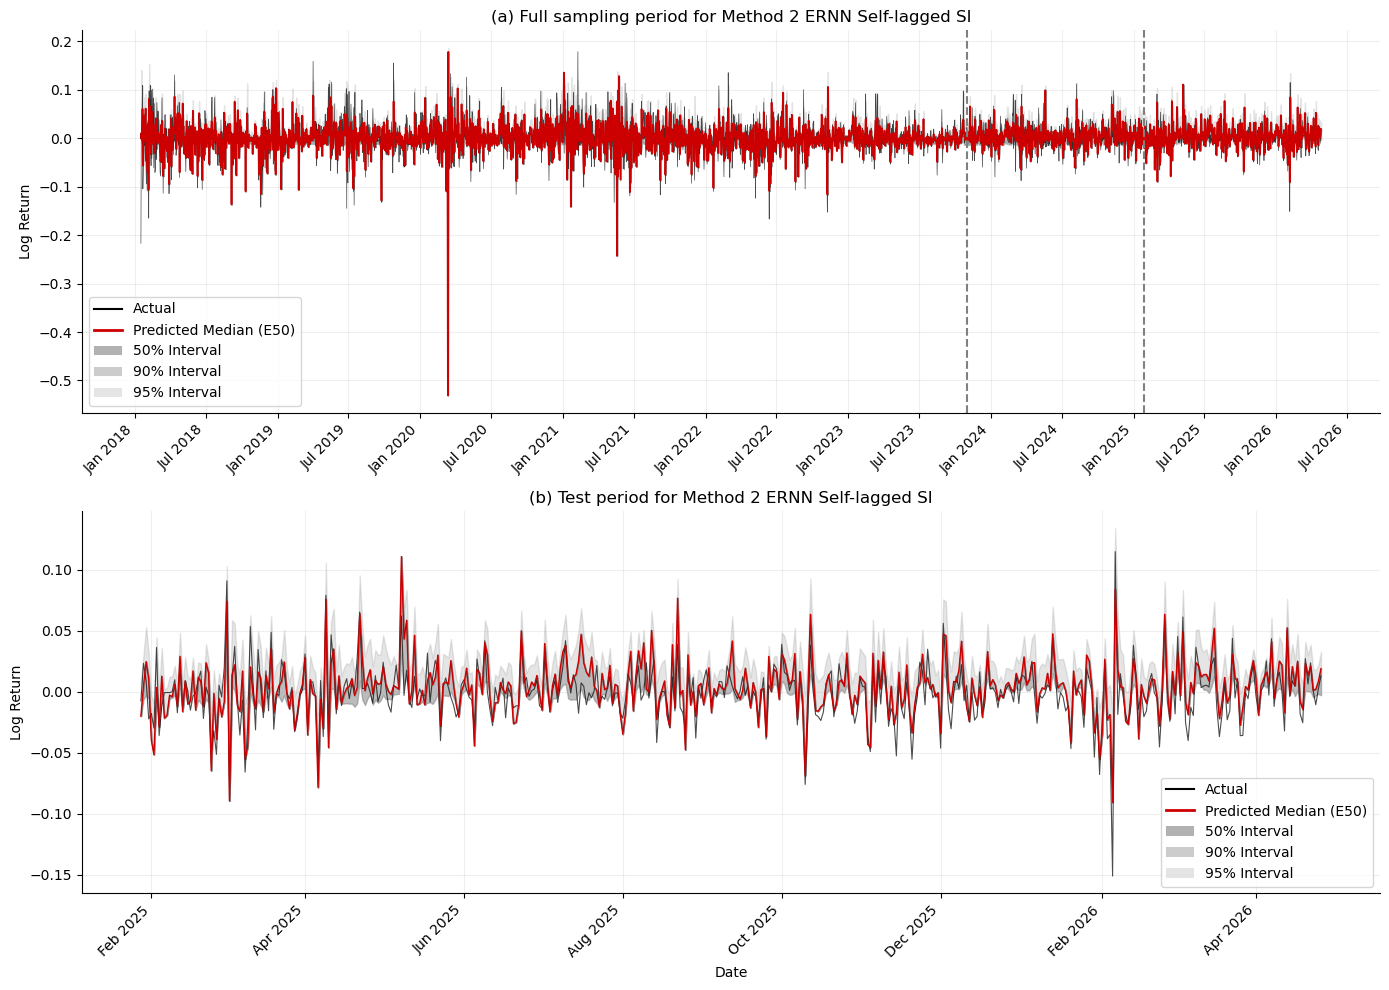

Plot saved to method2_sequential_ernn_si_self_predictions.png

TEST METRICS -- METHOD 2 ERNN SI SELF-LAGGED
  tau       NLL      ASE
0.025 -2.171055 0.000054
0.050 -2.377552 0.000058
0.250 -2.635696 0.000120
0.500 -2.732185 0.000095
0.750 -2.778815 0.000071
0.950 -2.269765 0.000051
0.975 -2.362959 0.000023

Average NLL: -2.475432
Average ASE: 0.00006731

CROSSOVER ANALYSIS -- FINAL METHOD 2 HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Metrics saved to method2_sequential_ernn_si_self_test_metrics.csv


In [27]:
# ============================================================
# Plot and evaluate Method 2
# Sequential ERNN SI Self-lagged
# ============================================================

import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# Load checkpoint if models are not in memory
# ============================================================

if 'm2_ernn_self_si_final_models' not in globals():
    checkpoint = torch.load(
        'method2_sequential_ernn_si_self_best.pt',
        map_location='cpu',
        weights_only=False
    )

    m2_ernn_self_si_final_models = {}

    for tau in checkpoint['estimation_order']:
        saved_model = checkpoint[
            'models'
        ][str(tau)]

        model = M2SequentialERNNSISelf(
            input_dim=X_train.shape[1],
            config=saved_model['config'],
            direction=saved_model['direction']
        )

        model.load_state_dict(
            saved_model['state_dict']
        )

        model.eval()

        m2_ernn_self_si_final_models[
            tau
        ] = model


# ============================================================
# Full-sample predictions
# ============================================================

m2_ernn_self_si_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

m2_ernn_self_si_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

m2_ernn_self_si_all_predictions = {}
m2_ernn_self_si_all_care = {}
m2_ernn_self_si_all_fnn = {}
m2_ernn_self_si_all_sigma = {}

for tau in m2_ernn_self_si_order:
    model = m2_ernn_self_si_final_models[
        tau
    ]

    reference_tau = (
        m2_ernn_self_si_reference[tau]
    )

    if reference_tau is None:
        reference_prediction = None
    else:
        reference_prediction = (
            m2_ernn_self_si_all_predictions[
                reference_tau
            ]
        )

    model.eval()

    with torch.no_grad():
        (
            prediction,
            sigma,
            care_output,
            fnn_output
        ) = model(
            y=m2_ernn_self_si_y_all,
            X=m2_ernn_self_si_X_all,
            reference=reference_prediction
        )

    m2_ernn_self_si_all_predictions[
        tau
    ] = prediction.detach()

    m2_ernn_self_si_all_care[
        tau
    ] = care_output.detach()

    m2_ernn_self_si_all_fnn[
        tau
    ] = fnn_output.detach()

    m2_ernn_self_si_all_sigma[
        tau
    ] = sigma.detach()


m2_ernn_self_si_all_preds_np = {
    tau: prediction.cpu().numpy()
    for tau, prediction
    in m2_ernn_self_si_all_predictions.items()
}


# ============================================================
# Sample information
# ============================================================

m2_ernn_self_si_test_start = (
    len(train_df) + len(val_df)
)

m2_ernn_self_si_all_dates = df.index
m2_ernn_self_si_test_dates = test_df.index

m2_ernn_self_si_y_all_np = (
    df['log_return'].values
)

m2_ernn_self_si_y_test_np = (
    test_df['log_return'].values
)

test_slice = slice(
    m2_ernn_self_si_test_start,
    None
)


# ============================================================
# Plot
# ============================================================

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'

legend_elements = [
    Line2D(
        [0], [0],
        color=actual_color,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=median_color,
        linewidth=2,
        label='Predicted Median (E50)'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.60,
        label='50% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.40,
        label='90% Interval'
    ),
    Patch(
        facecolor=interval_color,
        alpha=0.20,
        label='95% Interval'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# Full sample
ax = axes[0]

ax.plot(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_y_all_np,
    color=actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.500],
    color=median_color,
    linewidth=1.2
)

ax.fill_between(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.025],
    m2_ernn_self_si_all_preds_np[0.975],
    color=interval_color,
    alpha=0.20
)

ax.fill_between(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.050],
    m2_ernn_self_si_all_preds_np[0.950],
    color=interval_color,
    alpha=0.40
)

ax.fill_between(
    m2_ernn_self_si_all_dates,
    m2_ernn_self_si_all_preds_np[0.250],
    m2_ernn_self_si_all_preds_np[0.750],
    color=interval_color,
    alpha=0.60
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--'
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--'
)

ax.set_title(
    '(a) Full sampling period for '
    'Method 2 ERNN Self-lagged SI'
)

ax.set_ylabel('Log Return')
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.2)


# Test sample
ax2 = axes[1]

ax2.plot(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_y_test_np,
    color=actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.500
    ][test_slice],
    color=median_color,
    linewidth=1.0
)

ax2.fill_between(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.025
    ][test_slice],
    m2_ernn_self_si_all_preds_np[
        0.975
    ][test_slice],
    color=interval_color,
    alpha=0.20
)

ax2.fill_between(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.050
    ][test_slice],
    m2_ernn_self_si_all_preds_np[
        0.950
    ][test_slice],
    color=interval_color,
    alpha=0.40
)

ax2.fill_between(
    m2_ernn_self_si_test_dates,
    m2_ernn_self_si_all_preds_np[
        0.250
    ][test_slice],
    m2_ernn_self_si_all_preds_np[
        0.750
    ][test_slice],
    color=interval_color,
    alpha=0.60
)

ax2.set_title(
    '(b) Test period for '
    'Method 2 ERNN Self-lagged SI'
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(handles=legend_elements)
ax2.grid(True, alpha=0.2)


for axis, interval in zip(
    axes,
    [6, 2]
):
    axis.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )

    axis.xaxis.set_major_locator(
        mdates.MonthLocator(
            interval=interval
        )
    )

    plt.setp(
        axis.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)

plt.tight_layout()

m2_ernn_self_si_plot_name = (
    'method2_sequential_ernn_si_self_predictions.png'
)

plt.savefig(
    m2_ernn_self_si_plot_name,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f'Plot saved to '
    f'{m2_ernn_self_si_plot_name}'
)


# ============================================================
# Test metrics
# ============================================================

m2_ernn_self_si_y_test = (
    m2_ernn_self_si_y_all[
        m2_ernn_self_si_test_start:
    ]
)

metric_rows = []

for tau in m2_ernn_self_si_tau_levels:
    prediction_test = (
        m2_ernn_self_si_all_predictions[
            tau
        ][m2_ernn_self_si_test_start:]
    )

    sigma = (
        m2_ernn_self_si_all_sigma[tau]
    )

    test_nll = m2_ernn_self_si_loss(
        y=m2_ernn_self_si_y_test,
        e_hybrid=prediction_test,
        sigma=sigma,
        tau=tau
    ).item()

    test_ase = (
        m2_ernn_self_si_compute_ase(
            y=m2_ernn_self_si_y_test,
            e_hybrid=prediction_test,
            tau=tau
        )
    )

    metric_rows.append({
        'tau': tau,
        'NLL': test_nll,
        'ASE': test_ase
    })


m2_ernn_self_si_metrics_df = (
    pd.DataFrame(metric_rows)
)

average_nll = (
    m2_ernn_self_si_metrics_df[
        'NLL'
    ].mean()
)

average_ase = (
    m2_ernn_self_si_metrics_df[
        'ASE'
    ].mean()
)

print('\n' + '=' * 68)
print(
    'TEST METRICS -- METHOD 2 '
    'ERNN SI SELF-LAGGED'
)
print('=' * 68)

print(
    m2_ernn_self_si_metrics_df.to_string(
        index=False
    )
)

print(
    f'\nAverage NLL: {average_nll:.6f}'
)

print(
    f'Average ASE: {average_ase:.8f}'
)


# ============================================================
# Crossover analysis
# ============================================================

adjacent_pairs = [
    (0.025, 0.050),
    (0.050, 0.250),
    (0.250, 0.500),
    (0.500, 0.750),
    (0.750, 0.950),
    (0.950, 0.975)
]

tail_pairs = [
    (0.025, 0.050),
    (0.950, 0.975)
]

total_violations = 0
tail_violations = 0
crossover_rows = []

print('\n' + '=' * 68)
print(
    'CROSSOVER ANALYSIS -- '
    'FINAL METHOD 2 HYBRID OUTPUT'
)
print('=' * 68)

for lower, upper in adjacent_pairs:
    lower_test = (
        m2_ernn_self_si_all_predictions[
            lower
        ][m2_ernn_self_si_test_start:]
    )

    upper_test = (
        m2_ernn_self_si_all_predictions[
            upper
        ][m2_ernn_self_si_test_start:]
    )

    violations = int(
        (
            lower_test > upper_test
        ).sum().item()
    )

    rate = (
        violations / len(lower_test)
    )

    total_violations += violations

    if (lower, upper) in tail_pairs:
        tail_violations += violations

    crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': violations,
        'Rate': rate
    })

    tail_label = (
        ' <-- TAIL'
        if (lower, upper) in tail_pairs
        else ''
    )

    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} '
        f'({100 * rate:.2f}%)'
        f'{tail_label}'
    )


total_rate = (
    total_violations
    / (
        len(m2_ernn_self_si_y_test)
        * 6
    )
)

tail_rate = (
    tail_violations
    / (
        len(m2_ernn_self_si_y_test)
        * 2
    )
)

print(
    f'\nTotal violations: '
    f'{total_violations} '
    f'({100 * total_rate:.2f}%)'
)

print(
    f'Tail violations: '
    f'{tail_violations} '
    f'({100 * tail_rate:.2f}%)'
)


# ============================================================
# Save results
# ============================================================

m2_ernn_self_si_metrics_df.to_csv(
    'method2_sequential_ernn_si_self_test_metrics.csv',
    index=False
)

pd.DataFrame(
    crossover_rows
).to_csv(
    'method2_sequential_ernn_si_self_crossover.csv',
    index=False
)

print(
    '\nMetrics saved to '
    'method2_sequential_ernn_si_self_test_metrics.csv'
)

# Cross over dealing 3

In [30]:
"""Method 3, Specification 1: Hybrid ERNN SI self-lagged.

Run this after the notebook has created the four tensors
``y_train``, ``X_train``, ``y_val`` and ``X_val``.

The median is the corresponding original hybrid model.  Every non-median
network predicts a raw adjacent gap; ``softplus`` makes that gap positive and
the target level is reconstructed from its already-fitted adjacent reference.
There is no fixed epsilon boundary, max/min projection, or crossover penalty.
"""

from __future__ import annotations

import copy
from pathlib import Path

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ---------------------------------------------------------------------------
# User settings
# ---------------------------------------------------------------------------

LEVELS = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
ESTIMATION_ORDER = [0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025]
REFERENCE_LEVEL = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}
DIRECTION = {
    0.500: None,
    0.750: "upper",
    0.950: "upper",
    0.975: "upper",
    0.250: "lower",
    0.050: "lower",
    0.025: "lower",
}

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026
PSI_MARGIN = 1e-4
INITIAL_DELTA_BIAS = -4.6  # softplus(-4.6) is about 0.01; trainable.
OUTPUT_DIR = Path("method3_spacing_ernn_si_self_results")

# This standalone chunk estimates only the model supplied by the user:
# Hybrid ERNN, symmetric indirect form, self-lagged recursion.
MODELS_TO_RUN = [("ernn", "si", "self")]


def validate_notebook_inputs():
    required = ("y_train", "X_train", "y_val", "X_val")
    missing = [name for name in required if name not in globals()]
    if missing:
        raise NameError(
            "Create these notebook tensors before running Method 3: "
            + ", ".join(missing)
        )
    for y_name, x_name in (("y_train", "X_train"), ("y_val", "X_val")):
        y_value, x_value = globals()[y_name], globals()[x_name]
        if not isinstance(y_value, torch.Tensor) or not isinstance(x_value, torch.Tensor):
            raise TypeError(f"{y_name} and {x_name} must be torch tensors.")
        if y_value.ndim != 1 or x_value.ndim != 2 or len(y_value) != len(x_value):
            raise ValueError(f"{y_name} must be (T,) and {x_name} must be (T,p).")


# ---------------------------------------------------------------------------
# Generic Method 3 model
# ---------------------------------------------------------------------------

class Method3SpacingModel(nn.Module):
    """One sequential level model.

    direction=None is the median hybrid model.  Otherwise the network is a
    pure learned-spacing model and deliberately has no redundant statistical
    or mixing parameters.
    """

    def __init__(self, input_dim, config, distribution, form, lag, direction=None):
        super().__init__()
        if distribution not in {"qrnn", "ernn"}:
            raise ValueError("distribution must be 'qrnn' or 'ernn'.")
        if form not in {"s", "a", "si"}:
            raise ValueError("form must be 's', 'a', or 'si'.")
        if lag not in {"self", "cross"}:
            raise ValueError("lag must be 'self' or 'cross'.")

        self.distribution = distribution
        self.form = form
        self.lag = lag
        self.direction = direction

        # Statistical and mixing parameters are identifiable only for median.
        if direction is None:
            self.persistence_raw = nn.Parameter(torch.tensor(1.386))
            self.news1_raw = nn.Parameter(torch.tensor(0.3))
            if form in {"a", "si"}:
                self.news2_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        previous_dim = fnn_input_dim
        for index in range(config["n_hidden_layers"]):
            hidden_dim = config[f"hidden_dim_{index}"]
            layers.append(nn.Linear(previous_dim, hidden_dim))
            if config["layernorm"]:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._activation(config["activation"]))
            if config["dropout"] > 0:
                layers.append(nn.Dropout(config["dropout"]))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.fnn = nn.Sequential(*layers)
        self._initialise_fnn(config["weight_init"])

        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, INITIAL_DELTA_BIAS)

    @staticmethod
    def _activation(name):
        return {
            "relu": nn.ReLU(),
            "elu": nn.ELU(),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }[name]

    def _initialise_fnn(self, method):
        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if method == "glorot":
                    nn.init.xavier_uniform_(module.weight)
                else:
                    nn.init.kaiming_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def _statistical_update(self, previous_state, previous_y):
        persistence = torch.sigmoid(self.persistence_raw)
        news1 = F.softplus(self.news1_raw)
        if self.form == "s":
            return persistence * previous_state + news1 * torch.abs(previous_y)
        if self.form == "a":
            news2 = F.softplus(self.news2_raw)
            return (
                persistence * previous_state
                + news1 * torch.clamp(previous_y, min=0)
                + news2 * torch.clamp(-previous_y, min=0)
            )
        news2 = F.softplus(self.news2_raw)
        absolute_y = torch.abs(previous_y)
        return (
            persistence * previous_state
            + news1 * absolute_y
            + news2 * previous_state * absolute_y
        )

    def forward(self, y, X, q_reference=None, initial_state=None, initial_y=None):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # Six non-median models: directly learn a positive adjacent spacing.
        if self.direction is not None:
            if q_reference is None:
                raise ValueError("Non-median levels require q_reference.")
            reference = q_reference.detach()
            raw_delta = self.fnn(
                torch.cat((X, reference.unsqueeze(1)), dim=1)
            ).squeeze(-1)
            delta = F.softplus(raw_delta)
            prediction = reference + delta if self.direction == "upper" else reference - delta
            return prediction, torch.zeros_like(prediction), raw_delta, delta, sigma

        # Median: original hybrid statistical-neural specification.
        if (initial_state is None) != (initial_y is None):
            raise ValueError("initial_state and initial_y must be supplied together.")
        has_initial_state = initial_state is not None
        previous_state = initial_state if has_initial_state else y.new_zeros(())
        fnn_median = self.fnn(X).squeeze(-1)
        psi = (1.0 - PSI_MARGIN) * torch.sigmoid(self.psi_raw)
        predictions, statistical_outputs = [], []

        for t in range(len(y)):
            if t == 0 and not has_initial_state:
                statistical_t = y.new_zeros(())
                hybrid_t = y.new_zeros(())
            else:
                previous_y = initial_y if t == 0 else y[t - 1]
                statistical_t = self._statistical_update(previous_state, previous_y)
                hybrid_t = psi * statistical_t + (1.0 - psi) * fnn_median[t]
            statistical_outputs.append(statistical_t)
            predictions.append(hybrid_t)
            # Settled convention used by the earlier code:
            # self -> previous pure statistical output; cross -> previous hybrid.
            previous_state = statistical_t if self.lag == "self" else hybrid_t

        prediction = torch.stack(predictions)
        statistical = torch.stack(statistical_outputs)
        return prediction, statistical, fnn_median, None, sigma


# ---------------------------------------------------------------------------
# Distribution-specific objectives and calibration metrics
# ---------------------------------------------------------------------------

def single_level_nll(y, location, sigma, level, distribution):
    residual = y - location
    level_tensor = torch.tensor(level, dtype=y.dtype, device=y.device)
    if distribution == "qrnn":
        indicator = (residual < 0).to(y.dtype)
        rho = residual * (level_tensor - indicator)
        return (
            -torch.log(level_tensor * (1.0 - level_tensor))
            + torch.log(sigma)
            + rho / sigma
        ).mean()

    weight = torch.abs(level_tensor - (residual < 0).to(y.dtype))
    omega = weight * residual.square()
    constant = (
        torch.log(
            torch.sqrt(torch.pi / level_tensor)
            + torch.sqrt(torch.pi / (1.0 - level_tensor))
        )
        - np.log(2.0)
    )
    return (torch.log(sigma) + constant + omega / sigma.square()).mean()


def qrnn_calibration(y, location, level):
    if level <= 0.5:
        empirical = (y <= location).float().mean().item()
        target = level
    else:
        empirical = (y > location).float().mean().item()
        target = 1.0 - level
    crp = empirical / target
    return {"hit_rate": (y <= location).float().mean().item(),
            "hre": abs((y <= location).float().mean().item() - level),
            "calibration": crp,
            "calibration_penalty": (crp - 1.0) ** 2}


def ernn_calibration(y, location, level):
    residual = y - location
    weights = torch.where(
        residual >= 0,
        torch.full_like(residual, level),
        torch.full_like(residual, 1.0 - level),
    )
    ase = (weights * residual.square()).mean().item()
    return {"ase": ase, "calibration": ase, "calibration_penalty": ase}


# ---------------------------------------------------------------------------
# Tuning helpers
# ---------------------------------------------------------------------------

def suggest_config(trial):
    config = {
        "n_hidden_layers": trial.suggest_int("n_hidden_layers", 1, 3),
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "gelu", "tanh"]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "layernorm": trial.suggest_categorical("layernorm", [True, False]),
        "weight_init": trial.suggest_categorical("weight_init", ["glorot", "he"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw"]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 1e-4),
        "gradient_clip": trial.suggest_categorical("gradient_clip", [0.1, 1.0, 5.0]),
        "patience": trial.suggest_categorical("patience", [10, 20, 30]),
    }
    for index in range(config["n_hidden_layers"]):
        config[f"hidden_dim_{index}"] = trial.suggest_int(f"hidden_dim_{index}", 32, 256)
    return config


def make_optimizer(model, config):
    optimizer_class = torch.optim.Adam if config["optimizer"] == "adam" else torch.optim.AdamW
    return optimizer_class(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])


def median_validation_state(model, statistical_train, prediction_train):
    return statistical_train[-1] if model.lag == "self" else prediction_train[-1]


def predict_train_val(model, direction, q_reference_train=None, q_reference_val=None):
    model.eval()
    with torch.no_grad():
        q_train, stat_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )
        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_state=median_validation_state(model, stat_train, q_train),
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(y_val, X_val, q_reference_val)
    return q_train.detach(), q_val.detach(), delta_train, delta_val, sigma.detach()


def train_config(spec, config, level, direction, q_ref_train, q_ref_val, seed):
    distribution, form, lag = spec
    torch.manual_seed(seed)
    model = Method3SpacingModel(
        X_train.shape[1], config, distribution, form, lag, direction
    )
    optimizer = make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5, min_lr=1e-6
    )
    best_loss, counter, best_state = float("inf"), 0, None

    for _ in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        q_train, _, _, _, sigma = model(y_train, X_train, q_ref_train)
        loss = single_level_nll(y_train[1:], q_train[1:], sigma, level, distribution)
        if not torch.isfinite(loss):
            return None
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, q_val, _, _, sigma_val = predict_train_val(
                model, direction, q_ref_train, q_ref_val
            )
            val_loss = single_level_nll(y_val, q_val, sigma_val, level, distribution)
        scheduler.step(val_loss.item())
        if val_loss.item() < best_loss:
            best_loss, counter = val_loss.item(), 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= config["patience"]:
                break

    if best_state is None:
        return None
    model.load_state_dict(best_state)
    return model


def transformed_median_parameters(model):
    if model.direction is not None:
        return {}
    result = {
        "persistence": torch.sigmoid(model.persistence_raw).item(),
        "news1": F.softplus(model.news1_raw).item(),
        "psi": ((1.0 - PSI_MARGIN) * torch.sigmoid(model.psi_raw)).item(),
    }
    result["news2"] = (
        F.softplus(model.news2_raw).item() if hasattr(model, "news2_raw") else np.nan
    )
    return result


def evaluate(model, level, direction, q_ref_train, q_ref_val):
    _, q_val, _, delta_val, sigma = predict_train_val(
        model, direction, q_ref_train, q_ref_val
    )
    metrics = {
        "nll": single_level_nll(
            y_val, q_val, sigma, level, model.distribution
        ).item(),
        "sigma": (F.softplus(model.sigma_raw) + 1e-6).item(),
        "mean_delta": np.nan if delta_val is None else delta_val.mean().item(),
        "min_delta": np.nan if delta_val is None else delta_val.min().item(),
        "max_delta": np.nan if delta_val is None else delta_val.max().item(),
        "sd_delta": np.nan if delta_val is None else delta_val.std(unbiased=False).item(),
    }
    metrics.update(
        qrnn_calibration(y_val, q_val, level)
        if model.distribution == "qrnn"
        else ernn_calibration(y_val, q_val, level)
    )
    metrics.update(transformed_median_parameters(model))
    return metrics


def select_trial(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and "calibration_penalty" in trial.user_attrs
    ]
    if not trials:
        raise RuntimeError("No valid completed Optuna trials.")
    for rank, trial in enumerate(sorted(trials, key=lambda x: x.user_attrs["nll"]), 1):
        trial._rank_nll = rank
    for rank, trial in enumerate(
        sorted(trials, key=lambda x: x.user_attrs["calibration_penalty"]), 1
    ):
        trial._rank_calibration = rank
    best = min(
        trials,
        key=lambda x: (
            x._rank_nll + x._rank_calibration,
            x.user_attrs["nll"],
            x.user_attrs["calibration_penalty"],
            x.number,
        ),
    )
    return best, trials


def count_crossovers(predictions):
    matrix = torch.stack([predictions[level] for level in LEVELS], dim=1)
    violations = matrix[:, :-1] > matrix[:, 1:]
    pair_counts = violations.sum(dim=0)
    return {
        "crossover": int(violations.sum().item()),
        "tail": int((pair_counts[0] + pair_counts[-1]).item()),
    }


def run_one_model(spec):
    distribution, form, lag = spec
    model_key = f"{distribution}_{form}_{lag}"
    model_dir = OUTPUT_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    print("\n" + "=" * 78)
    print(f"METHOD 3 SPACING: {distribution.upper()} {form.upper()} {lag.upper()}")
    print("=" * 78)

    models, configs, metrics_by_level = {}, {}, {}
    train_predictions, val_predictions = {}, {}
    train_deltas, val_deltas = {}, {}

    for order_index, level in enumerate(ESTIMATION_ORDER):
        reference_level = REFERENCE_LEVEL[level]
        direction = DIRECTION[level]
        q_ref_train = None if reference_level is None else train_predictions[reference_level]
        q_ref_val = None if reference_level is None else val_predictions[reference_level]
        seed = BASE_SEED + 1000 * MODELS_TO_RUN.index(spec) + order_index

        def objective(trial):
            config = suggest_config(trial)
            model = train_config(
                spec, config, level, direction, q_ref_train, q_ref_val, seed
            )
            if model is None:
                return float("inf")
            trial_metrics = evaluate(model, level, direction, q_ref_train, q_ref_val)
            for name, value in trial_metrics.items():
                trial.set_user_attr(name, value)
            return trial_metrics["nll"]

        print(
            f"Level={level:.3f} | reference={reference_level} | "
            f"direction={direction} | trials={N_TRIALS}"
        )
        study = optuna.create_study(
            direction="minimize", sampler=TPESampler(seed=seed)
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
        best_trial, valid_trials = select_trial(study)

        ranking_records = []
        for trial in valid_trials:
            record = {
                "distribution": distribution,
                "form": form,
                "lag": lag,
                "level": level,
                "reference_level": reference_level,
                "direction": direction,
                "trial": trial.number,
                "nll": trial.user_attrs["nll"],
                "calibration": trial.user_attrs["calibration"],
                "calibration_penalty": trial.user_attrs["calibration_penalty"],
                "rank_nll": trial._rank_nll,
                "rank_calibration": trial._rank_calibration,
                "sum_rank": trial._rank_nll + trial._rank_calibration,
            }
            record.update(trial.user_attrs)
            record.update(trial.params)
            ranking_records.append(record)
        pd.DataFrame(ranking_records).sort_values(
            ["sum_rank", "nll", "calibration_penalty"]
        ).to_csv(model_dir / f"ranking_level_{level:.3f}.csv", index=False)

        best_config = best_trial.params.copy()
        final_model = train_config(
            spec, best_config, level, direction, q_ref_train, q_ref_val, seed
        )
        if final_model is None:
            raise RuntimeError(f"Selected refit failed for {model_key}, level={level}.")
        final_metrics = evaluate(
            final_model, level, direction, q_ref_train, q_ref_val
        )
        q_train, q_val, delta_train, delta_val, _ = predict_train_val(
            final_model, direction, q_ref_train, q_ref_val
        )
        models[level], configs[level] = final_model, best_config
        metrics_by_level[level] = final_metrics
        train_predictions[level], val_predictions[level] = q_train, q_val
        train_deltas[level], val_deltas[level] = delta_train, delta_val

        print(
            f"Selected trial #{best_trial.number} | "
            f"val NLL={final_metrics['nll']:.6f} | "
            f"calibration={final_metrics['calibration']:.6f} | "
            f"mean delta={final_metrics['mean_delta']:.6f}"
        )

    crossing = count_crossovers(val_predictions)
    average_nll = float(np.mean([metrics_by_level[x]["nll"] for x in LEVELS]))
    if distribution == "qrnn":
        average_secondary = float(np.mean([metrics_by_level[x]["hre"] for x in LEVELS]))
        secondary_name = "hre"
    else:
        average_secondary = float(np.mean([metrics_by_level[x]["ase"] for x in LEVELS]))
        secondary_name = "ase"

    checkpoint = {
        "model_name": f"Method 3 spacing {distribution.upper()} {form.upper()} {lag}",
        "specification": "learned_positive_time_varying_adjacent_spacing",
        "distribution": distribution,
        "form": form,
        "lag": lag,
        "levels": LEVELS,
        "estimation_order": ESTIMATION_ORDER,
        "reference_level": REFERENCE_LEVEL,
        "direction": DIRECTION,
        "configs": configs,
        "model_state_dicts": {level: model.state_dict() for level, model in models.items()},
        "validation_metrics": metrics_by_level,
        "validation_summary": {
            "average_nll": average_nll,
            f"average_{secondary_name}": average_secondary,
            **crossing,
        },
    }
    checkpoint_path = model_dir / f"method3_spacing_{model_key}_best.pt"
    torch.save(checkpoint, checkpoint_path)

    level_rows = []
    for level in LEVELS:
        level_rows.append({"level": level, **metrics_by_level[level]})
    pd.DataFrame(level_rows).to_csv(model_dir / "validation_by_level.csv", index=False)

    summary = {
        "distribution": distribution,
        "form": form.upper(),
        "lag": lag,
        "average_nll": average_nll,
        "average_hre": average_secondary if distribution == "qrnn" else np.nan,
        "average_ase": average_secondary if distribution == "ernn" else np.nan,
        **crossing,
        "checkpoint": str(checkpoint_path),
    }
    pd.DataFrame([summary]).to_csv(model_dir / "validation_summary.csv", index=False)
    print(f"Saved {checkpoint_path}")
    return summary


def main():
    validate_notebook_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summaries = []
    for spec in MODELS_TO_RUN:
        summaries.append(run_one_model(spec))
        pd.DataFrame(summaries).to_csv(
            OUTPUT_DIR / "method3_ernn_si_self_validation_summary.csv", index=False
        )
    print("\nMethod 3 ERNN SI self-lagged estimation is complete.")
    print(pd.DataFrame(summaries).to_string(index=False))


if __name__ == "__main__":
    main()

[I 2026-08-16 14:48:12,842] A new study created in memory with name: no-name-0ea2bfc3-a537-43c1-a54d-4968f040f6c2



METHOD 3 SPACING: ERNN SI SELF
Level=0.500 | reference=None | direction=None | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 14:48:57,718] Trial 0 finished with value: 0.8024671673774719 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 0.8024671673774719.
[I 2026-08-16 14:49:38,048] Trial 1 finished with value: -0.22770589590072632 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -0.22770589590072632.
[I 2026-08-16 14:49:44,982] Trial 2 finished with value: 0.8978094458580017 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.37112272198735796, 'layernorm': Tru

[I 2026-08-16 17:32:32,586] A new study created in memory with name: no-name-3f545a4c-fe84-4937-8e6e-047dc1d53679


...

[I 2026-08-16 18:09:01,232] Trial 0 finished with value: 0.504104495048523 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 0.504104495048523.
[I 2026-08-16 18:09:05,896] Trial 1 finished with value: -0.7730656266212463 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is trial 1 with value: -0.7730656266212463.
[I 2026-08-16 18:09:08,590] Trial 2 finished with value: 1.4520741701126099 and parameters: {'n_hidden_layers': 2, 'activat

[I 2026-08-16 18:14:21,660] A new study created in memory with name: no-name-a3d97622-6aa8-4d54-91d1-f52c7b42289b


Selected trial #161 | val NLL=-2.528287 | calibration=0.000049 | mean delta=0.011684
Level=0.025 | reference=0.05 | direction=lower | trials=200


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-08-16 18:14:28,408] Trial 0 finished with value: 0.6449094414710999 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 0.6449094414710999.
[I 2026-08-16 18:14:34,610] Trial 1 finished with value: 1.5522116422653198 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim_2': 66}. Best is trial 0 with value: 0.6449094414710999.
[I 2026-08-16 18:14:36,514] Trial 2 finished with value: 1.696600317955017 and parameters: {'n_hidden_l